# 03 · Lake Ngami: water observations and missing evidence

**Time:** 40 minutes · **Audience:** undergraduate / introductory graduate GIS and Earth science.

**By the end:** Trace a measured extract to its STAC assets and test a water-detection threshold.

[Run in JupyterLite](https://jltobias.github.io/JupyterLite-zarr-sql-views/lite/lab/index.html?path=03_deafrica_water.ipynb) · [Earth lab](https://jltobias.github.io/JupyterLite-zarr-sql-views/lab/) · [Sources and licenses](https://jltobias.github.io/JupyterLite-zarr-sql-views/book/credits.html)

Run cells from top to bottom with **Shift+Enter**. The first kernel start downloads Python WebAssembly packages.
The bundled exercises need no data-service account. Save a copy with **File → Save and Export Notebook As** before clearing browser storage.

![Four-stage workflow: STAC discovery, Zarr reading, SQL selection, linked views](assets/pipeline.svg)

In [1]:
from course import *
import numpy as np
import matplotlib.pyplot as plt
print('Ready: Python + NumPy + local teaching data')

Ready: Python + NumPy + local teaching data


## 1. Establish provenance before mapping

These observations come from **Digital Earth Africa WOfS annual summaries** for 2018, 2020, and 2022.
The preparation script reads frequency and clear-observation count, samples a 48 × 48 geographic grid with nearest-neighbour resampling,
and masks locations with fewer than five clear observations. Native COG pixels are 30 m in EPSG:6933.
Our coarse geographic sample is **not** an area-averaged raster and must not be summed into square kilometres.

In [2]:
meta, water = load_cube('ngami')
provenance = json.loads(Path('data/deafrica-provenance.json').read_text())
print(provenance['method'])
for item in provenance['records']:
    print(item['year'], item['item_id'], item['frequency_url'])

Nearest-neighbour point sampling on a 48 by 48 geographic grid; count_clear < 5 masked; not an area average.
2018 2b69dbd8-6ff2-5062-b82c-60ae1e77277c https://deafrica-services.s3.af-south-1.amazonaws.com/wofs_ls_summary_annual/1-0-0/x203/y050/2018--P1Y/wofs_ls_summary_annual_x203y050_2018--P1Y_frequency.tif
2020 acd1574e-bb31-5cd2-aa19-5e6ee77c231d https://deafrica-services.s3.af-south-1.amazonaws.com/wofs_ls_summary_annual/1-0-0/x203/y050/2020--P1Y/wofs_ls_summary_annual_x203y050_2020--P1Y_frequency.tif
2022 199183db-4086-526b-b113-7fbfecf19bf7 https://deafrica-services.s3.af-south-1.amazonaws.com/wofs_ls_summary_annual/1-0-0/x203/y050/2022--P1Y/wofs_ls_summary_annual_x203y050_2022--P1Y_frequency.tif


## 2. Compare maps on the same colour scale

With independent colour scales, a small change can appear dramatic. Use the same zero-to-one scale for every year.

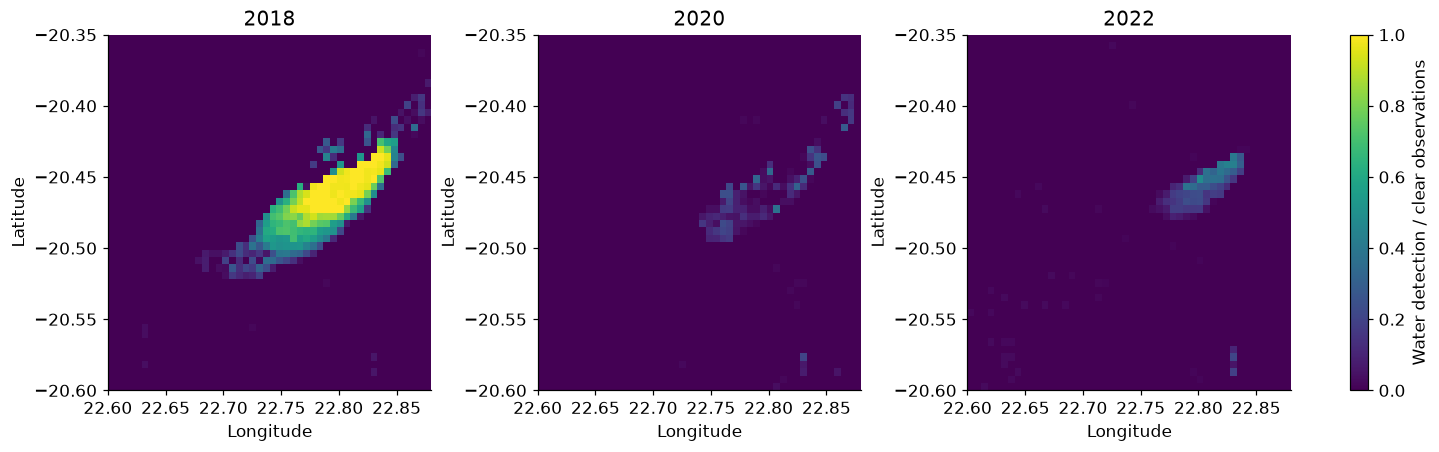

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
for t, ax in enumerate(axes):
    image = ax.pcolormesh(meta['lon'], meta['lat'], water[t], vmin=0, vmax=1, cmap='viridis', shading='nearest')
    ax.set(title=meta['times'][t], xlabel='Longitude', ylabel='Latitude')
fig.colorbar(image, ax=axes, label='Water detection / clear observations')
plt.show()

## 3. Hold the sample support constant

Comparing changing sets of valid pixels can change a mean even if the underlying water state is unchanged.
An intersection mask trades coverage for comparability. This still does not remove cloud-season sampling bias.

In [4]:
common = np.all(np.isfinite(water), axis=0)
print('Common support:', common.sum(), 'sampled cells')
thresholds = [0.2, 0.5, 0.8]
for threshold in thresholds:
    print(threshold, [int(np.count_nonzero((water[t] > threshold) & common)) for t in range(3)])

Common support: 2304 sampled cells
0.2 [180, 17, 28]
0.5 [127, 0, 0]
0.8 [69, 0, 0]


In [5]:
con=sql_connection(meta, water)
list(con.execute('SELECT t, COUNT(value), ROUND(AVG(value), 3) FROM cells GROUP BY t'))

[(0, 2304, 0.056), (1, 2304, 0.005), (2, 2304, 0.006)]

## 4. Move between observation and interpretation

Try the time slider, click a cell, then compare its history with the selected-cell mean.
Three sparse annual snapshots cannot attribute changes to climate change. River inflows, antecedent rain,
evaporation, abstraction, and observation quality are candidate explanations requiring additional evidence.
Water presence is also different from household access to reliable, safe water.

In [6]:
lab('ngami','map')

## Try it yourself

Compare thresholds on common support and each year’s own support. Explain why both tables are useful.

## Check your reasoning

Changing quality masks affect denominators. A sound comparison states the mask, the resampling method, the threshold, and the available years.

## Evidence journal

Write four sentences: **what I observed; how I calculated it; what this cannot establish; what evidence I need next**.
For any figure you reuse, retain its units, date or scenario, data origin, transformations, and attribution.

## Sources and credit

- [Digital Earth Africa WOfS specifications and limitations](https://docs.digitalearthafrica.org/en/latest/data_specs/Landsat_WOfS_specs.html), CC BY 4.0 data.
- [IPCC AR6 WGII, Chapter 9: Africa](https://www.ipcc.ch/report/ar6/wg2/chapter/chapter-9/). Linked context, not redistributed data.

Teaching adaptation of [dzole0311/zarr-sql-views](https://github.com/dzole0311/zarr-sql-views), ISC.
Original teaching code and prose: JupyterLite-zarr-sql-views contributors, ISC. Data keep their separate licenses.